In [ ]:
# core
import os
import numpy as np
import pandas as pd

# modeling
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_predict, cross_val_score

# metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# plots
import matplotlib.pyplot as plt

# utils
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [2]:
# path to your training data
data_path = "./data/train_mp.csv"  # change if needed
df = pd.read_csv(data_path)

# columns to exclude from features (as requested)
non_feature_cols = {
    "material_id", "formula", "composition", "composition_obj",
    "formation_energy_per_atom", "band_gap"
}

# feature columns = all except the excluded ones (then keep only numeric)
feature_cols = [c for c in df.columns if c not in non_feature_cols]
X_all = df[feature_cols].select_dtypes(include=[np.number]).copy()

# label
target_col = "formation_energy_per_atom"
y_all = df[target_col].astype(float).copy()

# basic checks
print("n_samples:", len(df))
print("n_features (numeric):", X_all.shape[1])
print("first 5 feature columns:", feature_cols[:5])
X_all.head()


n_samples: 6419
n_features (numeric): 250
first 5 feature columns: ['H', 'He', 'Li', 'Be', 'B']


,H,He,Li,Be,B,C,N,O,F,Ne,...,MagpieData range GSmagmom,MagpieData mean GSmagmom,MagpieData avg_dev GSmagmom,MagpieData mode GSmagmom,MagpieData minimum SpaceGroupNumber,MagpieData maximum SpaceGroupNumber,MagpieData range SpaceGroupNumber,MagpieData mean SpaceGroupNumber,MagpieData avg_dev SpaceGroupNumber,MagpieData mode SpaceGroupNumber
0,0.0,0,0.0,0,0.0,0.750000,0.0,0.0,0.0,0,...,0.000000,0.00000,0.000000,0.000000,194.0,229.0,35.0,202.750000,13.125000,194.0
1,0.0,0,0.0,0,0.0,0.200000,0.0,0.0,0.0,0,...,2.110663,1.68853,0.675412,2.110663,194.0,229.0,35.0,222.000000,11.200000,229.0
2,0.0,0,0.0,0,0.0,0.558824,0.0,0.0,0.0,0,...,0.000000,0.00000,0.000000,0.000000,194.0,194.0,0.0,194.000000,0.000000,194.0
3,0.0,0,0.0,0,0.0,0.600000,0.0,0.0,0.0,0,...,0.000000,0.00000,0.000000,0.000000,194.0,194.0,0.0,194.000000,0.000000,194.0
4,0.0,0,0.0,0,0.0,0.555556,0.0,0.0,0.0,0,...,0.000000,0.00000,0.000000,0.000000,194.0,225.0,31.0,207.777778,15.308642,194.0


In [3]:
# train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=RANDOM_STATE
)

# simple imputation (median) to handle any missing values
X_train = X_train.fillna(X_train.median(numeric_only=True))
X_test  = X_test.fillna(X_train.median(numeric_only=True))  # use train medians

print("train shape:", X_train.shape, "| test shape:", X_test.shape)


train shape: (5135, 250) | test shape: (1284, 250)


In [ ]:
RANDOM_STATE = 42

xgb_base = XGBRegressor(
    random_state=RANDOM_STATE,
    n_jobs=1,
    tree_method="hist"
)

# a reasonable, compact grid (adjust as needed)
param_grid = {
    "n_estimators": [300, 600],
    "max_depth": [3, 6, 10],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "min_child_weight": [1, 3],
    "reg_alpha": [0.0, 0.1],   # L1 regularization
    "reg_lambda": [1.0, 5.0]   # L2 regularization
}

gscv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# optimize for RMSE; return other scores for inspection
gscv = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=gscv,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

gscv.fit(X_train, y_train)
best_xgb = gscv.best_estimator_
print("best params:", gscv.best_params_)
print("best cv RMSE:", -gscv.best_score_)


Fitting 5 folds for each of 384 candidates, totalling 1920 fits
best params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 6, 'min_child_weight': 3, 'n_estimators': 300, 'reg_alpha': 0.0, 'reg_lambda': 5.0, 'subsample': 0.8}
best cv RMSE: 0.3757967849983544


In [5]:
import math
from math import sqrt

def eval_regression(y_true, y_pred, label=""):
    # ensure 1D arrays
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    # robust RMSE for all sklearn versions
    mse  = mean_squared_error(y_true, y_pred)   # default returns MSE
    rmse = sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"{label} RMSE: {rmse:.3f} | MAE: {mae:.3f} | R2: {r2:.3f}")
    return rmse, mae, r2

# predictions
yhat_tr = best_xgb.predict(X_train)
yhat_te = best_xgb.predict(X_test)

print("== training ==")
tr_metrics = eval_regression(y_train, yhat_tr, "train")

print("\n== test ==")
te_metrics = eval_regression(y_test, yhat_te, "test")


== training ==
train RMSE: 0.283 | MAE: 0.132 | R2: 0.899

== test ==
test RMSE: 0.433 | MAE: 0.216 | R2: 0.786


In [6]:
# cross-validated metrics across the full dataset (same as RF style)
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# RMSE (fallback-safe)
try:
    cv_rmse = -cross_val_score(best_xgb, X_all, y_all, cv=cv,
                               scoring="neg_root_mean_squared_error", n_jobs=-1)
except ValueError:
    mse_scores = -cross_val_score(best_xgb, X_all, y_all, cv=cv,
                                  scoring="neg_mean_squared_error", n_jobs=-1)
    cv_rmse = np.sqrt(mse_scores)

cv_mae  = -cross_val_score(best_xgb, X_all, y_all, cv=cv,
                           scoring="neg_mean_absolute_error", n_jobs=-1)
cv_r2   =  cross_val_score(best_xgb, X_all, y_all, cv=cv, scoring="r2", n_jobs=-1)

print(f"cv RMSE: mean={cv_rmse.mean():.3f} ± {cv_rmse.std():.3f}")
print(f"cv MAE : mean={cv_mae.mean():.3f} ± {cv_mae.std():.3f}")
print(f"cv R2  : mean={cv_r2.mean():.3f} ± {cv_r2.std():.3f}")

yhat_cv = cross_val_predict(best_xgb, X_all, y_all, cv=cv, n_jobs=-1)


cv RMSE: mean=0.384 ± 0.030
cv MAE : mean=0.195 ± 0.013
cv R2  : mean=0.817 ± 0.018


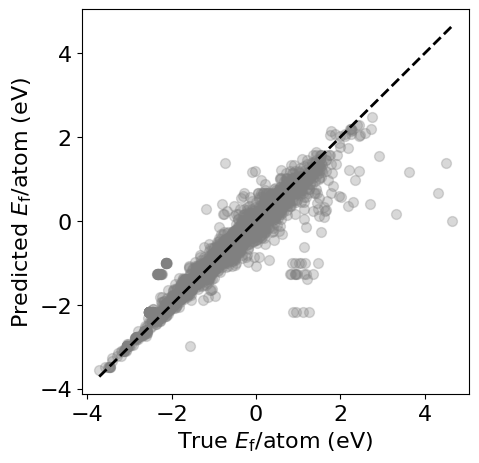

In [11]:
# --- Train parity ---

plt.figure(figsize=(5,5))
plt.scatter(
    y_train, yhat_tr,
    s=50, alpha=0.3,
    c="grey")
lims = [min(y_train.min(), yhat_tr.min()), max(y_train.max(), yhat_tr.max())]
plt.plot(
    lims, lims,
    linewidth=2,
    color="black",
    linestyle="--")
plt.xlabel(r"True $E_\mathrm{f}$/atom (eV)", fontsize=16)
plt.ylabel(r"Predicted $E_\mathrm{f}$/atom (eV)", fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.savefig('./visual/fig_s1e.jpg', format='jpg', dpi=500, bbox_inches='tight')
plt.show()


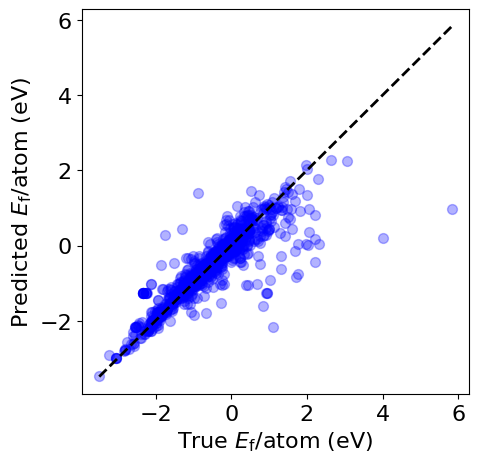

In [12]:
# --- Test parity ---
plt.figure(figsize=(5,5))
plt.scatter(
    y_test, yhat_te,
    s=50, alpha=0.3,
    c="blue"  # scatter color for test set
)

lims = [min(y_test.min(), yhat_te.min()), max(y_test.max(), yhat_te.max())]
plt.plot(
    lims, lims,
    linewidth=2,
    color="black",
    linestyle="--"  # dashed line
)

# use consistent notation: E_f/atom
plt.xlabel(r"True $E_\mathrm{f}$/atom (eV)", fontsize=16)
plt.ylabel(r"Predicted $E_\mathrm{f}$/atom (eV)", fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.savefig('./visual/fig2c.jpg', format='jpg', dpi=500, bbox_inches='tight')
plt.show()


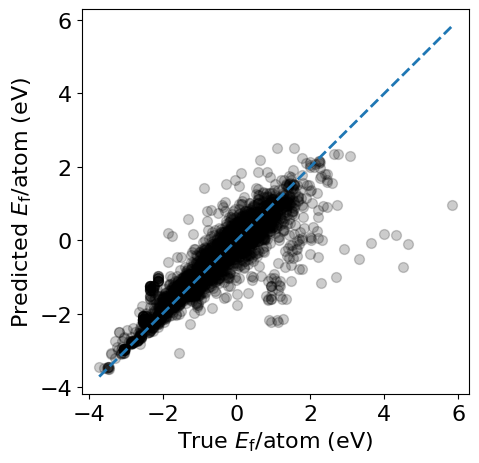

In [13]:
plt.figure(figsize=(5,5))
plt.scatter(y_all, yhat_cv,s=50, alpha=0.2,c="black") # scatter color for cv set
lims = [min(y_all.min(), yhat_cv.min()), max(y_all.max(), yhat_cv.max())]
plt.plot(
    lims, lims,
    linewidth=2,
    color="tab:blue",
    linestyle="--"  # dashed line
)

plt.xlabel(r"True $E_\mathrm{f}$/atom (eV)", fontsize=16)
plt.ylabel(r"Predicted $E_\mathrm{f}$/atom (eV)", fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.savefig('./visual/fig_s1f.jpg', format='jpg', dpi=500, bbox_inches='tight')
plt.show()


/tmp/ipykernel_1373551/1939090858.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


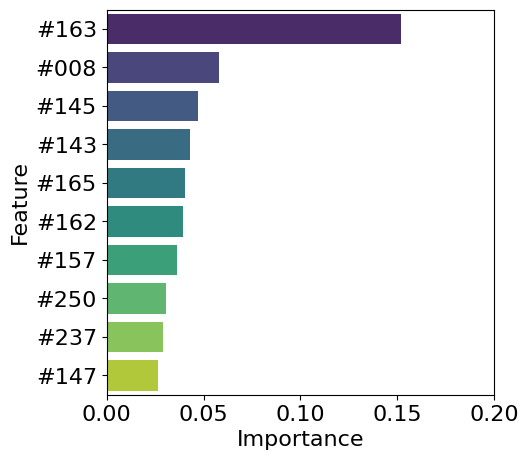

,Short name
MagpieData range Electronegativity,#163
O,#008
MagpieData range Column,#145
MagpieData minimum Column,#143
MagpieData avg_dev Electronegativity,#165
MagpieData maximum Electronegativity,#162
MagpieData range CovalentRadius,#157
MagpieData mode SpaceGroupNumber,#250
MagpieData avg_dev GSbandgap,#237
MagpieData avg_dev Column,#147


In [10]:
import seaborn as sns
import numpy as np

# rebuild feature importance series (native XGB importance)
importances = pd.Series(best_xgb.feature_importances_, index=X_train.columns)

# get top 10
imp_top = importances.sort_values(ascending=False).head(10)

# map original feature names → Feature #XXX
feature_map = {
    feat: f"#{str(X_train.columns.get_loc(feat)+1).zfill(3)}"
    for feat in imp_top.index
}

# relabel for plotting
imp_top_short = imp_top.rename(index=feature_map)

plt.figure(figsize=(5,5))
sns.barplot(
    x=imp_top_short.values,
    y=imp_top_short.index,
    palette="viridis"
)

plt.xlabel("Importance", fontsize=16)
plt.ylabel("Feature", fontsize=16)

# set xticks at 0.00, 0.05, 0.10, 0.15 …
max_val = imp_top_short.max()
plt.xticks(
    np.arange(0, max_val + 0.05, 0.05),
    fontsize=16
)
plt.yticks(fontsize=16)

plt.savefig('./visual/fig2d.jpg', format='jpg', dpi=500, bbox_inches='tight')
plt.show()

# lookup table for reference
lookup = pd.DataFrame.from_dict(feature_map, orient="index", columns=["Short name"])
display(lookup)

